DATACENTERS_DE file


Allocate demand to non included countries

In [48]:
# Compare the countries covered by the Balmorel datacenter demand table
# (DE_DATACENTER._old.inc) with those in the medium demand projections
import re
from pathlib import Path

import pandas as pd

# Folder with all input and output files used in this notebook
DATA_DIR = Path(r"C:\Balmorel\Data_python")

de_datacenter_path = DATA_DIR / "DE_DATACENTER._old.inc"
projections_path = DATA_DIR / "demand_projections_medium.txt"

# --- Read DE_DATACENTER._old.inc: the GAMS TABLE lies between the year header and ';'
lines = de_datacenter_path.read_text().splitlines()
header_idx = next(i for i, l in enumerate(lines) if re.match(r"^\s+\d{4}\b", l))
years = lines[header_idx].split()
rows = []
for line in lines[header_idx + 1:]:
    if line.strip() == ";":
        break
    if line.strip():
        region, *values = line.split()
        rows.append([region] + [float(v) for v in values])
De_demand = pd.DataFrame(rows, columns=["Region"] + years)

# Balmorel regions -> country codes used in the projections file
# (DK1/DK2 -> DK, SE1-SE4 -> SE, DE4-E/W/S/N -> DE; other regions are already countries)
De_demand["Country"] = De_demand["Region"].str.replace(r"^(DK|SE)\d$|^(DE)4-[EWSN]$",
                                                       lambda m: m.group(1) or m.group(2),
                                                       regex=True)

# --- Read demand_projections_medium.txt (tab-separated, first column = country)
demand_projections_medium = pd.read_csv(projections_path, sep="\t")
demand_projections_medium = demand_projections_medium.rename(
    columns={demand_projections_medium.columns[0]: "Country"}
)
demand_projections_medium["Country"] = demand_projections_medium["Country"].str.strip()

# --- Compare the two country sets
dc_countries = set(De_demand["Country"])
proj_countries = set(demand_projections_medium["Country"]) - {"Others"}  # 'Others' is an aggregate, not a country

print(f"Countries in DE_DATACENTER._old.inc: {len(dc_countries)}")
print(f"Countries in demand_projections_medium.txt (excl. 'Others'): {len(proj_countries)}\n")
print("In both:                       ", sorted(dc_countries & proj_countries))
print("Only in DE_DATACENTER._old.inc:     ", sorted(dc_countries - proj_countries))
print("Only in demand projections:    ", sorted(proj_countries - dc_countries))

Countries in DE_DATACENTER._old.inc: 27
Countries in demand_projections_medium.txt (excl. 'Others'): 14

In both:                        ['BE', 'DE', 'DK', 'ES', 'FIN', 'FR', 'IE', 'IT', 'NL', 'PL', 'SE']
Only in DE_DATACENTER._old.inc:      ['AT', 'BG', 'CY', 'CZ', 'EE', 'GR', 'HR', 'HU', 'LT', 'LU', 'LV', 'MT', 'PT', 'RO', 'SI', 'SK']
Only in demand projections:     ['CH', 'NO', 'UK']


In [49]:
# Identify countries present in De_demand but missing from demand_projections_medium
country_col = "Country"

de_countries = set(De_demand[country_col].dropna().str.strip())
projected_countries = set(
    demand_projections_medium[country_col].dropna().str.strip()
)

missing_countries = sorted(de_countries - projected_countries)

print("Missing countries:")
print(missing_countries)

Missing countries:
['AT', 'BG', 'CY', 'CZ', 'EE', 'GR', 'HR', 'HU', 'LT', 'LU', 'LV', 'MT', 'PT', 'RO', 'SI', 'SK']


2025 demand of the missing countries and their share of the missing total

In [50]:
# 2025 datacenter demand allocated to the countries in DE_DATACENTER._old.inc that are
# missing from demand_projections_medium, and each country's share of that subtotal
year = "2025"

# Recompute the missing countries so this cell does not depend on the previous one
missing_countries = sorted(
    set(De_demand["Country"]) - set(demand_projections_medium["Country"])
)

# Aggregate regions to countries (all missing countries are single-region, but this keeps it general)
demand_by_country = De_demand.groupby("Country")[year].sum()

missing_demand = (
    demand_by_country.loc[missing_countries]
    .sort_values(ascending=False)
    .to_frame(name=f"Demand {year} (MWh)")
)
missing_total = missing_demand[f"Demand {year} (MWh)"].sum()
missing_demand["Demand (TWh)"] = missing_demand[f"Demand {year} (MWh)"] / 1e6
missing_demand["Share of missing total (%)"] = (
    missing_demand[f"Demand {year} (MWh)"] / missing_total * 100
)

display(missing_demand.style.format({
    f"Demand {year} (MWh)": "{:,.0f}",
    "Demand (TWh)": "{:.3f}",
    "Share of missing total (%)": "{:.2f}",
}))

# Context: compare the subtotal with the whole table and with the 'Others' projection
# (DE_DATACENTER._old.inc is in MWh; demand_projections_medium is assumed to be in TWh)
table_total = demand_by_country.sum()
others_proj = demand_projections_medium.set_index("Country").loc["Others", year]

print(f"Total demand of missing countries in {year}: {missing_total:,.0f} MWh "
      f"({missing_total / 1e6:.3f} TWh)")
print(f"Share of all demand in DE_DATACENTER._old.inc:    {missing_total / table_total * 100:.2f} %")
print(f"'Others' in demand_projections_medium {year}: {others_proj:.3f} TWh")

,Demand 2025 (MWh),Demand (TWh),Share of missing total (%)
Country,,,
RO,"2,763,888",2.764,16.70
CZ,"2,048,503",2.049,12.38
HU,"1,961,568",1.962,11.85
PT,"1,631,579",1.632,9.86
BG,"1,520,460",1.520,9.19
AT,"1,493,930",1.494,9.03
GR,"1,173,022",1.173,7.09
SK,"1,001,599",1.002,6.05
HR,"684,467",0.684,4.14


Total demand of missing countries in 2025: 16,548,226 MWh (16.548 TWh)
Share of all demand in DE_DATACENTER._old.inc:    14.80 %
'Others' in demand_projections_medium 2025: 8.417 TWh


Allocate 'Others' from demand_projections_medium to the missing countries using their 2025 shares

In [51]:
# Split the 'Others' row of demand_projections_medium across the missing countries,
# using each country's 2025 share of the missing-country total (computed in the cell above),
# and save the result as a new file next to the original
import numpy as np

output_path = projections_path.with_name("demand_projections_medium_allocated.txt")

shares = missing_demand["Share of missing total (%)"] / 100  # fractions summing to 1
projections = demand_projections_medium.set_index("Country")
year_cols = list(projections.columns)
others = projections.loc["Others", year_cols]

# One row per missing country: Others(year) x share(country); the same share is applied to every year
allocated = pd.DataFrame(
    [others.values * s for s in shares.values],
    index=shares.index,
    columns=year_cols,
)

# Keep the original countries, drop 'Others' (now fully allocated) and append the missing countries
demand_projections_medium_allocated = pd.concat([projections.drop(index="Others"), allocated])
demand_projections_medium_allocated.index.name = None  # blank first header cell, as in the original file

# Check: the missing countries together must add up to the original 'Others' in every year
assert np.allclose(allocated.sum(), others), "Allocated values do not sum to 'Others'"

display(demand_projections_medium_allocated)

# Same layout as the original: tab-separated, blank top-left cell, Windows line endings
demand_projections_medium_allocated.to_csv(
    output_path, sep="\t", float_format="%.10g", lineterminator="\r\n"
)
print(f"Saved to {output_path}")

,2024,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035
DE,19.000000,20.166667,21.333333,22.500000,23.666667,24.833333,26.000000,28.400000,30.800000,33.200000,35.600000,38.000000
FR,13.000000,13.833333,14.666667,15.500000,16.333333,17.166667,18.000000,19.700000,21.400000,23.100000,24.800000,26.500000
UK,10.500000,10.766667,11.033333,11.300000,11.566667,11.833333,12.100000,14.780000,17.460000,20.140000,22.820000,25.500000
NL,8.000000,8.333333,8.666667,9.000000,9.333333,9.666667,10.000000,10.800000,11.600000,12.400000,13.200000,14.000000
IE,6.000000,6.533333,7.066667,7.600000,8.133333,8.666667,9.200000,10.360000,11.520000,12.680000,13.840000,15.000000
ES,5.200000,5.833333,6.466667,7.100000,7.733333,8.366667,9.000000,9.950000,10.900000,11.850000,12.800000,13.750000
NO,2.500000,2.833333,3.166667,3.500000,3.833333,4.166667,4.500000,6.100000,7.700000,9.300000,10.900000,12.500000
IT,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.250000,5.500000,6.750000,8.000000,9.250000
SE,2.300000,2.750000,3.200000,3.650000,4.100000,4.550000,5.000000,6.800000,8.600000,10.400000,12.200000,14.000000
FIN,1.400000,1.583333,1.766667,1.950000,2.133333,2.316667,2.500000,3.200000,3.900000,4.600000,5.300000,6.000000


Saved to C:\Balmorel\Data_python\demand_projections_medium_allocated.txt


In [52]:
# Check: for each year, the allocated demand of the missing countries must add up to
# the original 'Others' value in demand_projections_medium
others_original = demand_projections_medium.set_index("Country").loc["Others", year_cols]
missing_sum = demand_projections_medium_allocated.loc[missing_countries, year_cols].sum()

check = pd.DataFrame({
    "Others (original)": others_original,
    "Sum of missing countries": missing_sum,
})
check["Difference"] = check["Sum of missing countries"] - check["Others (original)"]
check["Match"] = np.isclose(check["Sum of missing countries"], check["Others (original)"])
check.index.name = "Year"

display(check)

if check["Match"].all():
    print("OK: the missing countries add up to 'Others' in every year.")
else:
    print("MISMATCH in years:", list(check.index[~check["Match"]]))


,Others (original),Sum of missing countries,Difference,Match
Year,,,,
2024,7.000000,7.000000,0.000000e+00,True
2025,8.416667,8.416667,0.000000e+00,True
2026,9.833333,9.833333,-1.776357e-15,True
2027,11.250000,11.250000,0.000000e+00,True
2028,12.666667,12.666667,0.000000e+00,True
2029,14.083333,14.083333,-1.776357e-15,True
2030,15.500000,15.500000,0.000000e+00,True
2031,17.000000,17.000000,0.000000e+00,True
2032,18.500000,18.500000,0.000000e+00,True


OK: the missing countries add up to 'Others' in every year.


In [53]:
# Export the allocated datacenter demand projections as a GAMS table, DE_DATACENTER(RRR,YYY),
# in the same format and unit (MWh) as DE_DATACENTER._old.inc
gams_path = DATA_DIR / "DE_DATACENTER.inc"

# TWh -> MWh (DE_DATACENTER._old.inc and Balmorel's DE are in MWh)
demand_mwh = demand_projections_medium_allocated * 1e6

# Countries modelled as several Balmorel regions (DE4-E/W/S/N, DK1/DK2, SE1-SE4) keep their country
# total from demand_projections_medium, split over the regions with each region's share of the
# country's demand in De_demand (DE_DATACENTER._old.inc) in the SAME year. Years not in DE_DATACENTER._old.inc
# (2024) use the nearest available year. NO is not in De_demand, so it is split equally over NO1-NO5.
dc = De_demand.set_index("Region")
dc_years = [y for y in dc.columns if y.isdigit()]
dc_multi = dc[dc.groupby("Country")["Country"].transform("size") > 1]

region_shares = dc_multi[dc_years] / dc_multi.groupby("Country")[dc_years].transform("sum")
region_shares = (region_shares.reindex(columns=demand_mwh.columns)
                 .bfill(axis=1).ffill(axis=1))              # fill 2024 from 2025
region_country = dc_multi["Country"].to_dict()

no_regions = ["NO1", "NO2", "NO3", "NO4", "NO5"]
region_shares = pd.concat([region_shares,
                           pd.DataFrame(1 / 5, index=no_regions, columns=demand_mwh.columns)])
region_country.update({r: "NO" for r in no_regions})

print("Regional shares used (%), selected years:")
display((region_shares[[y for y in ["2024", "2025", "2030", "2035"] if y in region_shares]] * 100)
        .set_index(pd.MultiIndex.from_arrays([region_shares.index.map(region_country), region_shares.index],
                                             names=["Country", "Region"]))
        .style.format("{:.1f}"))

rows = []
for country, values in demand_mwh.iterrows():
    regions = [r for r, c in region_country.items() if c == country]
    if regions:
        rows += [(r, values * region_shares.loc[r]) for r in regions]
    else:
        rows.append((country, values))
DE_DATACENTER = pd.DataFrame({r: v for r, v in rows}).T

# Check: each split country's regions add up to its total in demand_projections_medium in every year
for country in set(region_country.values()):
    regions = [r for r, c in region_country.items() if c == country]
    assert np.allclose(DE_DATACENTER.loc[regions].sum(), demand_mwh.loc[country]), f"{country} total changed"

# Check: splitting into regions must not change the total demand in any year
assert np.allclose(DE_DATACENTER.sum(), demand_mwh.sum()), "Regional split changed the totals"

# Write the GAMS TABLE with the same fixed-width layout as DE_DATACENTER._old.inc
label_w, col_w = 7, 14
header = " " * (label_w - 2) + "".join(f"{y:>{col_w}}" for y in DE_DATACENTER.columns)
lines = [
    "TABLE   DE_DATACENTER(RRR,YYY)   'Datacenter electricity consumption (MWh)'",
    header,
    " " * len(header),
]
for region, values in DE_DATACENTER.iterrows():
    lines.append(f"{region:<{label_w - 2}}" + "".join(f"{v:>{col_w}.6e}" for v in values))
lines += [
    ";",
    "* To use this table as the datacenter demand, uncomment the two lines below",
    "* DE(YYY,RRR,'DATACENTER')=DE_DATACENTER(RRR,YYY);",
    "* DE_DATACENTER(RRR,YYY)=0;",
]
gams_path.write_text("\n".join(lines) + "\n")

print(f"Saved {len(DE_DATACENTER)} regions x {DE_DATACENTER.shape[1]} years to {gams_path}")


Regional shares used (%), selected years:


Saved 41 regions x 12 years to C:\Balmorel\Data_python\DE_DATACENTER.inc


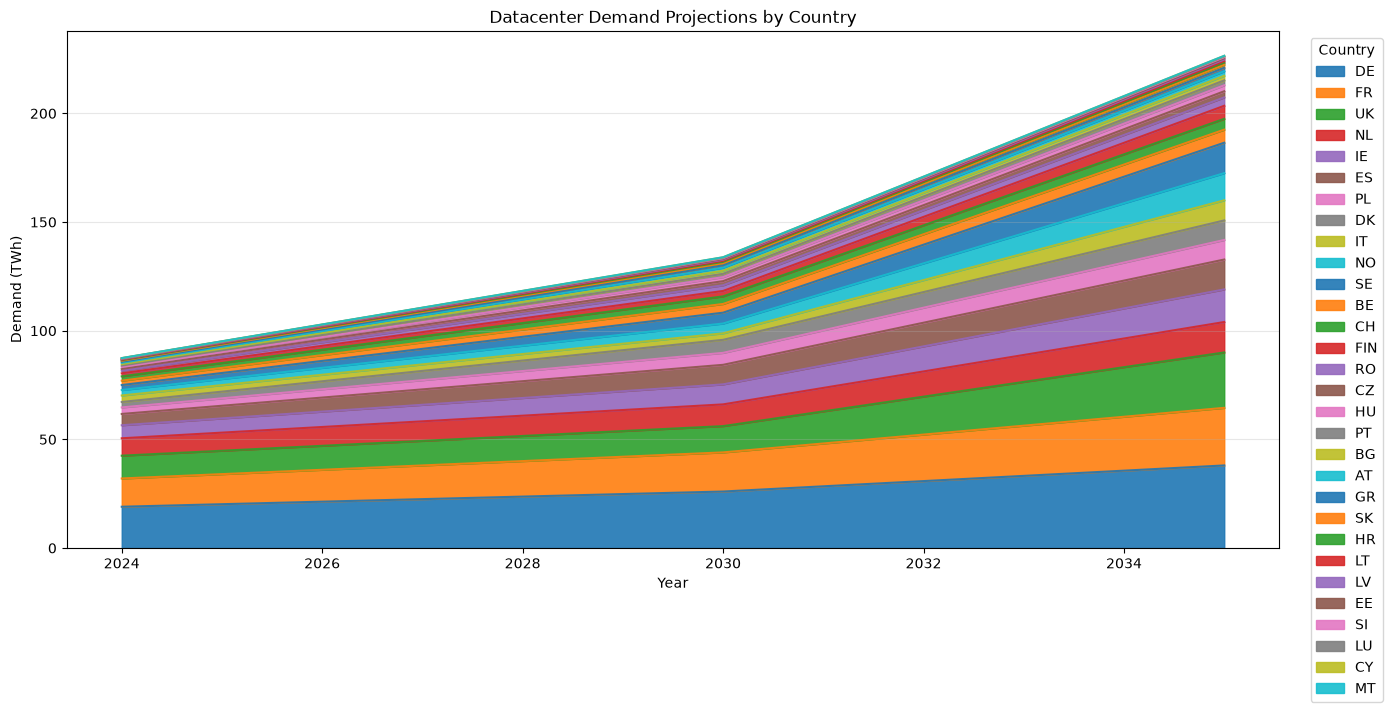

In [54]:
import matplotlib.pyplot as plt

# demand_projections_medium_allocated is in TWh, with countries as its index
plot_data = demand_projections_medium_allocated.sort_values(
    by="2025", ascending=False
).T

ax = plot_data.plot.area(
    figsize=(14, 7),
    stacked=True,
    alpha=0.9,
)

ax.set_title("Datacenter Demand Projections by Country")
ax.set_xlabel("Year")
ax.set_ylabel("Demand (TWh)")
ax.legend(
    title="Country",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Share of each sub-region in its country's datacenter demand, per year (DE_DATACENTER._old.inc)

In [55]:
# Share of each sub-region (DE4-E, DK1, SE1, ...) in its country's total datacenter demand,
# per year, from DE_DATACENTER._old.inc (De_demand is read in the first code cell)
year_cols_dc = [c for c in De_demand.columns if c.isdigit()]

# Only countries modelled as more than one Balmorel region
multi_region = De_demand[De_demand.groupby("Country")["Region"].transform("count") > 1]

country_total = multi_region.groupby("Country")[year_cols_dc].transform("sum")
subregion_shares = (multi_region[year_cols_dc] / country_total).set_index(
    pd.MultiIndex.from_frame(multi_region[["Country", "Region"]])
)

# Check: the sub-region shares of each country add up to 1 in every year
assert np.allclose(subregion_shares.groupby("Country").sum(), 1), "Shares do not sum to 1"

display((subregion_shares * 100).style.format("{:.1f}").set_caption("Share of country demand (%)"))

Check: sub-region shares in DE_DATACENTER.inc vs DE_DATACENTER._old.inc

In [56]:
# Sub-region shares in DE_DATACENTER.inc, per year, compared with the shares in DE_DATACENTER._old.inc
# (subregion_shares, computed in the cell above)
def read_gams_table(path):
    """Read a GAMS TABLE(RRR,YYY) in the DE_DATACENTER._old.inc layout into a DataFrame (regions x years)."""
    lines = Path(path).read_text().splitlines()
    header_idx = next(i for i, l in enumerate(lines) if re.match(r"^\s+\d{4}\b", l))
    years = lines[header_idx].split()
    rows = {}
    for line in lines[header_idx + 1:]:
        if line.strip() == ";":
            break
        if line.strip():
            region, *values = line.split()
            rows[region] = [float(v) for v in values]
    return pd.DataFrame.from_dict(rows, orient="index", columns=years)

new_table = read_gams_table(gams_path)

# Region -> country, same mapping as for De_demand (NO1-NO5 -> NO added, as NO is only in the new table)
new_country = new_table.index.str.replace(r"^(DK|SE|NO)\d$|^(DE)4-[EWSN]$",
                                          lambda m: m.group(1) or m.group(2), regex=True)
new_table = new_table.set_index(pd.MultiIndex.from_arrays([new_country, new_table.index],
                                                          names=["Country", "Region"]))

# Keep only countries with more than one region and divide by the country total per year
countries = new_table.index.get_level_values("Country")
multi = new_table[countries.map(countries.value_counts()) > 1]
new_shares = multi / multi.groupby(level="Country").transform("sum")

print("Sub-region shares in DE_DATACENTER.inc (%):")
display((new_shares * 100).style.format("{:.1f}"))

# Compare with DE_DATACENTER._old.inc for the regions and years present in both files
common_rows = new_shares.index.intersection(subregion_shares.index)
common_years = [y for y in new_shares.columns if y in subregion_shares.columns]
diff_pp = (new_shares.loc[common_rows, common_years]
           - subregion_shares.loc[common_rows, common_years]) * 100

print(f"\nDifference DE_DATACENTER - DE_DATACENTER._old (percentage points), years {common_years[0]}-{common_years[-1]}:")
display(diff_pp.style.format("{:+.1f}"))

# Tolerance of 0.001 percentage points: DE_DATACENTER.inc stores 7 significant digits, so
# shares read back from the file differ from the exact ones by rounding (~1e-5 pp)
matches = np.isclose(diff_pp, 0, atol=1e-3).all(axis=1)
for country in diff_pp.index.get_level_values("Country").unique():
    ok = matches[diff_pp.index.get_level_values("Country") == country].all()
    print(f"  {country}: {'matches in every year' if ok else 'does NOT match in every year'}")

only_new = sorted(set(new_shares.index.get_level_values("Country")) - set(subregion_shares.index.get_level_values("Country")))
only_new_years = [y for y in new_shares.columns if y not in subregion_shares.columns]
if only_new:
    print(f"  Not in DE_DATACENTER._old.inc, so not compared: {only_new}")
if only_new_years:
    print(f"  Years not in DE_DATACENTER._old.inc, so not compared: {only_new_years}")

Sub-region shares in DE_DATACENTER.inc (%):



Difference DE_DATACENTER - DE_DATACENTER._old (percentage points), years 2025-2035:


  DE: matches in every year
  SE: matches in every year
  DK: matches in every year
  Not in DE_DATACENTER._old.inc, so not compared: ['NO']
  Years not in DE_DATACENTER._old.inc, so not compared: ['2024']


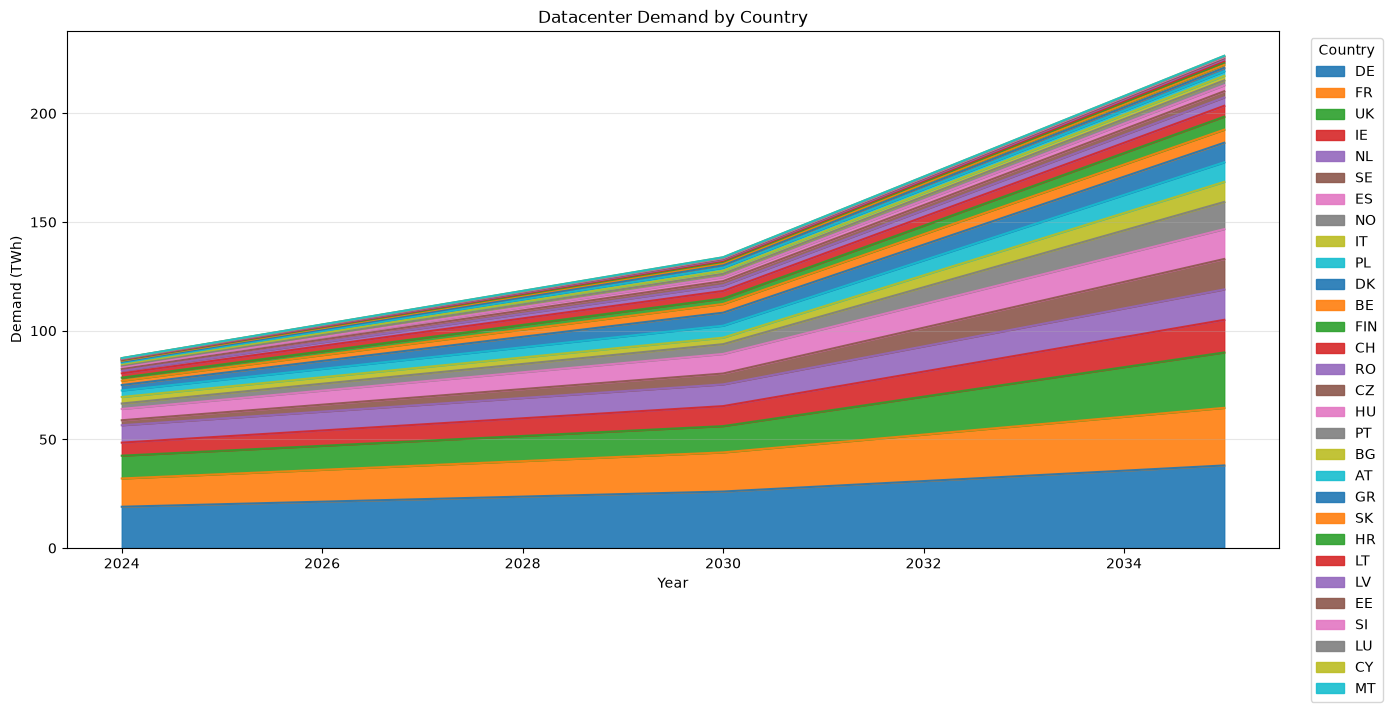

In [57]:
# Stacked datacenter demand by country (Balmorel sub-regions aggregated to their country)
# region_country (from the export cell) maps DE4-E/W/S/N, DK1/DK2, SE1-SE4 and NO1-NO5 to
# their country; all other regions are already countries
country_of = DE_DATACENTER.index.map(lambda r: region_country.get(r, r))
by_country = DE_DATACENTER.groupby(country_of).sum()

# Check: aggregating must not change the total demand in any year
assert np.allclose(by_country.sum(), DE_DATACENTER.sum()), "Aggregation changed the totals"

# Largest countries at the bottom of the stack
by_country = by_country.sort_values(by=by_country.columns[-1], ascending=False)
plot_data = (by_country / 1e6).T  # MWh to TWh, years on x-axis

ax = plot_data.plot.area(
    figsize=(14, 7),
    stacked=True,
    alpha=0.9,
)

ax.set_title("Datacenter Demand by Country")
ax.set_xlabel("Year")
ax.set_ylabel("Demand (TWh)")
ax.grid(axis="y", alpha=0.3)
ax.legend(
    title="Country",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()


In [58]:
target_path = Path(r"C:\Balmorel\base\data\DE_DATACENTER.inc")
target_path.parent.mkdir(parents=True, exist_ok=True)

target_path.write_text(gams_path.read_text())

print(f"Saved to {target_path}")

Saved to C:\Balmorel\base\data\DE_DATACENTER.inc


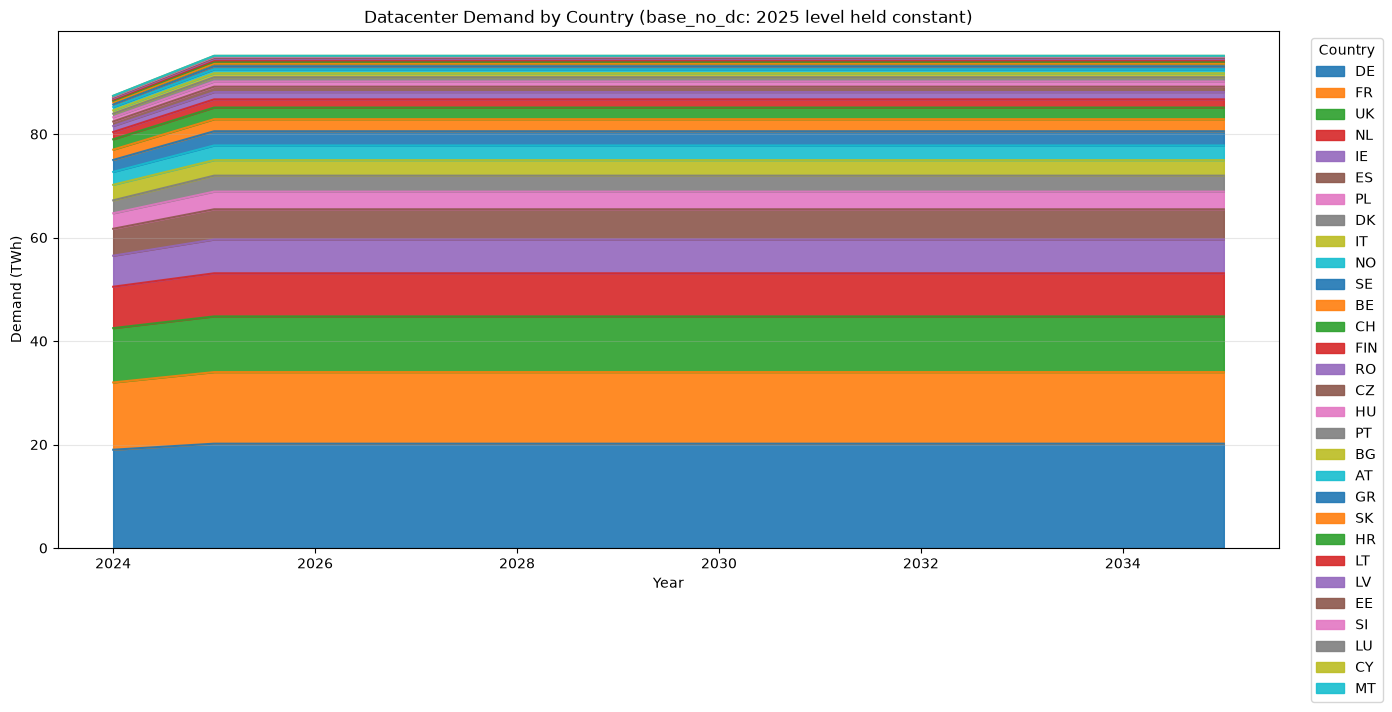

In [59]:
# Stacked datacenter demand by country for the no-growth scenario (base_no_dc):
# 2025 values held constant after 2025
import matplotlib.pyplot as plt

no_dc_path = Path(r"C:\Balmorel\base_no_dc\data\DE_DATACENTER.inc")
DE_DATACENTER_no_dc = read_gams_table(no_dc_path)  # regions x years, MWh

# Aggregate sub-regions (DE4-E/W/S/N, DK1/DK2, SE1-SE4, NO1-NO5) to their country
country_of_no_dc = DE_DATACENTER_no_dc.index.map(lambda r: region_country.get(r, r))
by_country_no_dc = DE_DATACENTER_no_dc.groupby(country_of_no_dc).sum()

# Check: aggregating must not change the total demand in any year
assert np.allclose(by_country_no_dc.sum(), DE_DATACENTER_no_dc.sum()), "Aggregation changed the totals"

# Largest countries at the bottom of the stack
by_country_no_dc = by_country_no_dc.sort_values(by=by_country_no_dc.columns[-1], ascending=False)
plot_data = (by_country_no_dc / 1e6).T  # MWh to TWh, years on x-axis

ax = plot_data.plot.area(
    figsize=(14, 7),
    stacked=True,
    alpha=0.9,
)

ax.set_title("Datacenter Demand by Country (base_no_dc: 2025 level held constant)")
ax.set_xlabel("Year")
ax.set_ylabel("Demand (TWh)")
ax.grid(axis="y", alpha=0.3)
ax.legend(
    title="Country",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()
